In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('A:/PROJECTS/Data Science Projects/churn-predictor/data/bank_churn.csv')

In [7]:
print('Shape: ', df.shape)

Shape:  (10000, 14)


In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


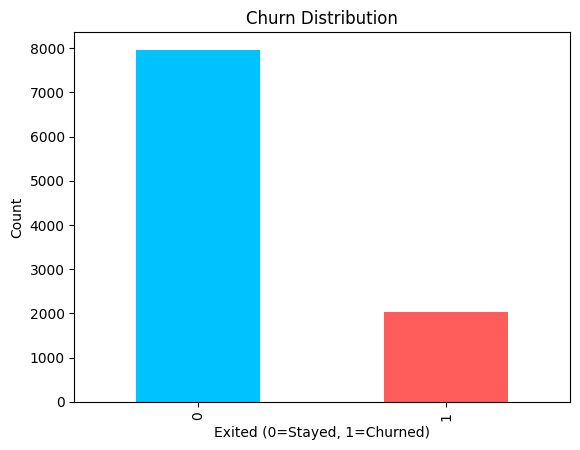

In [13]:
df['Exited'].value_counts().plot(kind = 'bar' , color = ['#00C2FF' , '#FF5C5C'])
plt.title('Churn Distribution')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Count')
plt.show()

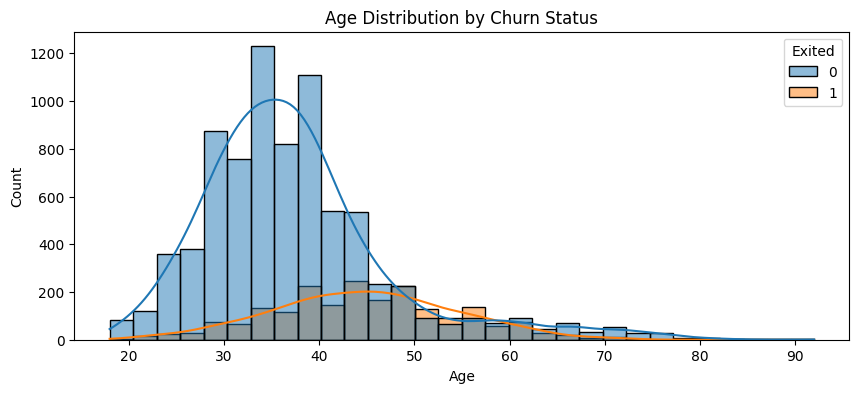

In [17]:
plt.figure(figsize = (10, 4))
sns.histplot(data = df, x= 'Age' , hue = 'Exited' , bins =30 , kde = True)
plt.title('Age Distribution by Churn Status')
plt.show()

#kde stands for Kernel Density Estimate

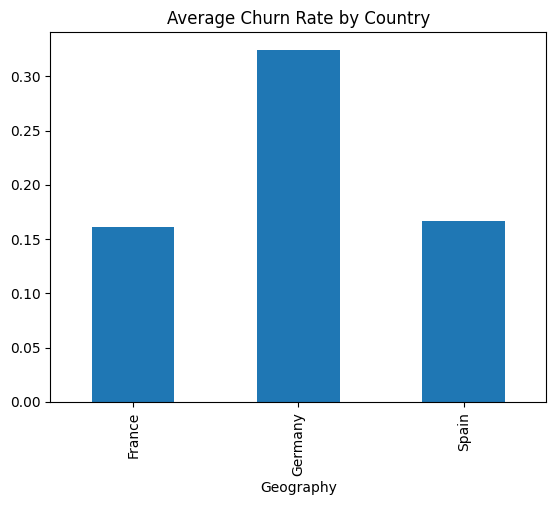

In [19]:
df.groupby('Geography')['Exited'].mean().plot(kind = 'bar')
plt.title('Average Churn Rate by Country')
plt.show()

# Since Exited is only 0s and 1s, the mean IS the churn rate

EDA revealed German customers churn at 2x the rate of other regions, making Geography one of the top predictive features.

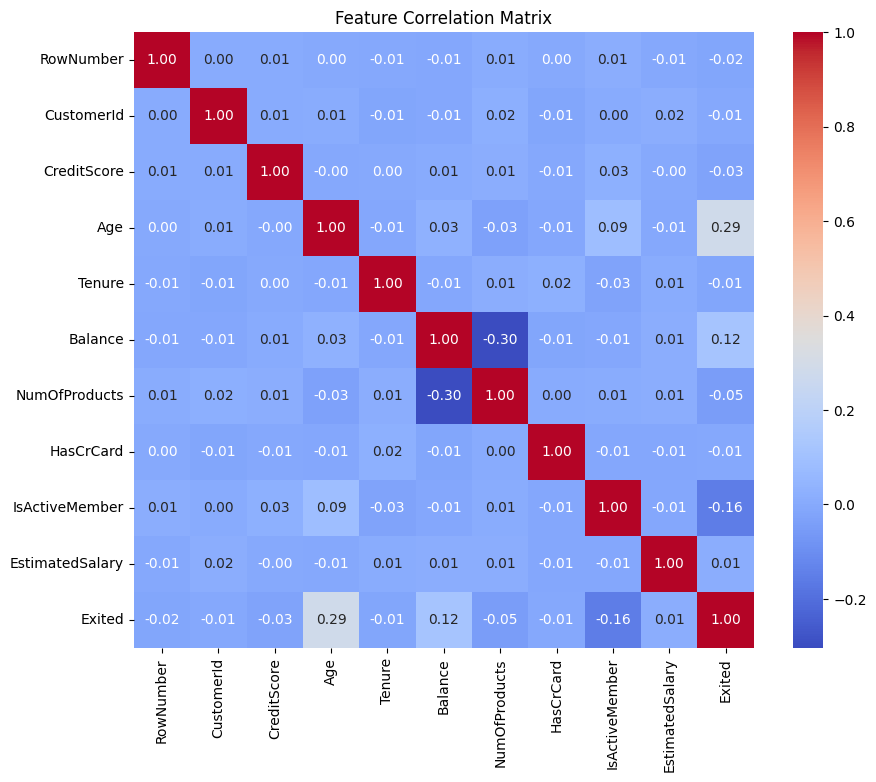

In [22]:
plt.figure(figsize = (10,8))
sns.heatmap(df.select_dtypes(include = 'number').corr(), annot = True, fmt = '.2f' , cmap = 'coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

The diagonal is always 1.0; every column is perfectly correlated with itself.
The most important column is Exited. Look at its row or column and find which features have the highest absolute values. Those are the strongest predictors. 

In this dataset, you'll notice:

Age has around 0.29 with Exited, a moderate positive correlation; older customers churn more
IsActiveMember has a negative correlation with Exited; active members churn less
Balance has a small positive correlation; higher balance customers are slightly more likely to churn

Two things to watch out for:

High correlation between two INPUT features (not Exited), for example, if Age and Tenure are highly correlated, they're giving the model the same information twice. 
This is called multicollinearity and can slightly hurt some models.
Low correlation with Exited doesn't always mean a feature is useless; sometimes two weak features combine to become a strong predictor together, which is something tree-based models like XGBoost are very good at discovering on their own